# 第5章 合併シミュレーション

BLPランダム係数ロジットモデルを用いた合併シミュレーションを行う。
限界費用の推定、合併後の均衡価格の計算、厚生分析を実施する。

## 1. Pythonに関する下準備

In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import warnings
import time

warnings.filterwarnings('ignore')

# 日本語フォント設定
for font_name in ['Hiragino Maru Gothic Pro', 'Hiragino Sans',
                   'IPAexGothic', 'Noto Sans CJK JP', 'Yu Gothic']:
    try:
        matplotlib.font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.family'] = font_name
        break
    except ValueError:
        continue

# パス設定
base_dir = Path('..')
intermediate_dir = base_dir / 'intermediate'
output_dir = base_dir / 'output'
output_dir.mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


## 2. データの読み込みと下準備

In [2]:
# Ch04で作成したデータを読み込む
data = pd.read_csv(intermediate_dir / 'data_for_estimation.csv')

# ダミー変数の作成

# 外国車ダミー
data['Foreign_d'] = (data['Type'] == 'Foreign').astype(int)

# FuelType=レギュラー のダミー
data['FuelRegular_d'] = (data['FuelType'] == 'レギュラー').astype(int)

# 年ダミー (2006を基準)
years = sorted(data['year'].unique())
for y in years:
    if y != 2006:
        data[f'year_{y}'] = (data['year'] == y).astype(int)

# capacity ダミー (4以下と5以上で分ける)
data['capacity_d'] = (data['capacity'] > 4).astype(int)

print(f"データサイズ: {data.shape}")
print(f"年: {years}")
print(f"年数: {len(years)}")


データサイズ: (1823, 60)
年: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
年数: 11


## 3. ランダム係数ロジットモデルの推定

コード自体はCh04とほぼ同様だが、X2がpriceのみ（ランダム係数が1つ）である。

In [3]:
# データをソートする (マーケット順、メーカー順、価格順)
data = data.sort_values(['year', 'Maker', 'price']).reset_index(drop=True)

# ---------- datalist に格納 ----------

# X1: 平均効用に入ってくる部分 (内生性がある価格を含む)
year_dummy_cols = [f'year_{y}' for y in sorted(data['year'].unique()) if y != 2006]

X1_cols = ['price', 'FuelEfficiency', 'hppw', 'size',
           'capacity_d', 'FuelRegular_d', 'Foreign_d'] + year_dummy_cols
X1 = np.column_stack([np.ones(len(data)), data[X1_cols].values])
X1_colnames = ['cons'] + X1_cols

# X2: ランダム係数とInteractする部分 (priceのみ)
X2 = data[['price']].values

# Z: 操作変数行列 (外生変数 + 追加的な操作変数)
# iv_GH_*を含むが、*_nestで終わるものは除外
iv_gh_cols = [c for c in data.columns if c.startswith('iv_GH') and not c.endswith('nest')]
Z_cols = ['FuelEfficiency', 'hppw', 'size',
          'capacity_d', 'FuelRegular_d', 'Foreign_d'] + year_dummy_cols + iv_gh_cols
Z = np.column_stack([np.ones(len(data)), data[Z_cols].values])

# 市場シェア
ShareVec = data['share'].values.reshape(-1, 1)

# マーケットインデックス
marketindex = data['year'].values
logitshare = data['logit_share'].values

# 観察数、年数
N = len(marketindex)
T = len(np.unique(marketindex))

print(f"N = {N}, T = {T}")
print(f"X1 shape: {X1.shape}")
print(f"X2 shape: {X2.shape}")
print(f"Z shape: {Z.shape}")


N = 1823, T = 11
X1 shape: (1823, 18)
X2 shape: (1823, 1)
Z shape: (1823, 23)


In [4]:
# 乱数を設定
np.random.seed(111)
Nsim = 1000
K2 = X2.shape[1]  # = 1 (priceのみ)
draw_vec = np.random.randn(K2 * Nsim)

# マーケットインデックスのダミー行列 (N x T)
uniquemarketindex = np.sort(np.unique(marketindex))
# mkt_denom_d[i, t] = 1 if observation i belongs to market t
mkt_denom_d = (marketindex.reshape(-1, 1) == uniquemarketindex.reshape(1, -1)).astype(float)

print(f"Nsim = {Nsim}")
print(f"K2 = {K2}")
print(f"mkt_denom_d shape: {mkt_denom_d.shape}")


Nsim = 1000
K2 = 1
mkt_denom_d shape: (1823, 11)


### 推定に必要な関数の定義

In [5]:
def calculate_mktshare(X2, mkt_denom_d, draw_vec, Nsim, delta, theta2):
    """市場シェアを計算する関数。"""
    K2 = len(theta2)
    # 非線形の要素: mu = X2 @ diag(theta2) @ draw_matrix
    draw_matrix = draw_vec[:K2 * Nsim].reshape(K2, Nsim)
    mu = X2 @ np.diag(theta2) @ draw_matrix  # (N, Nsim)

    # delta_mu = delta * 1_{1,Nsim} + mu
    delta_2d = delta.reshape(-1, 1) if delta.ndim == 1 else delta
    delta_mu = delta_2d @ np.ones((1, Nsim)) + mu
    exp_delta_mu = np.exp(delta_mu)

    T = mkt_denom_d.shape[1]

    # ロジット確率の分母: 市場ごとに和を計算
    # denom_temp = (exp_delta_mu^T @ mkt_denom_d)^T -> (T, Nsim)
    denom_temp = (exp_delta_mu.T @ mkt_denom_d).T
    denom_outside = np.ones((T, Nsim))  # exp(0) = 1
    denom_temp = denom_temp + denom_outside

    # denom は (N, Nsim) 行列
    denom = mkt_denom_d @ denom_temp

    # 個々の選択確率 (N, Nsim)
    s_jt_i = exp_delta_mu / denom

    # シェア (N,)
    s_jt = s_jt_i.mean(axis=1)

    return s_jt


def calculate_avg_utility_by_Berry_inversion(X2, mkt_denom_d, draw_vec,
                                              Nsim, ShareVec, delta_ini, theta2):
    """Berryインバージョンによる平均効用の計算。"""
    ShareVec_flat = ShareVec.flatten()
    exp_delta_old = np.exp(delta_ini.flatten())

    tol = 1e-11
    norm = 1e+10
    iter_count = 0

    while norm > tol and iter_count < 1000:
        delta_old = np.log(exp_delta_old)
        pred_mkt_share = calculate_mktshare(X2, mkt_denom_d, draw_vec,
                                             Nsim, delta_old, theta2)
        exp_delta_new = exp_delta_old * ShareVec_flat / pred_mkt_share
        norm = np.max(np.abs(exp_delta_new - exp_delta_old))
        exp_delta_old = exp_delta_new
        iter_count += 1

    return np.log(exp_delta_old)


In [6]:
def GMM_obj(theta2, X1, X2, Z, ShareVec, mkt_denom_d, draw_vec,
            Nsim, delta_ini, weight_mat_option, option=0):
    """GMM目的関数。
    option=0: 最適化の際 (スカラー値を返す)
    option=1: 推定値やmean utility(delta)を得る際 (辞書を返す)
    """
    theta2 = np.atleast_1d(theta2)

    # 縮小写像
    delta = calculate_avg_utility_by_Berry_inversion(
        X2, mkt_denom_d, draw_vec, Nsim, ShareVec, delta_ini, theta2
    )

    delta_2d = delta.reshape(-1, 1)

    # 重み行列 W
    if weight_mat_option == '2SLS':
        W = np.linalg.inv(Z.T @ Z)
    else:
        W = np.eye(Z.shape[1])

    # 線形パラメータ: theta1 = (X1'Z W Z'X1)^{-1} X1'Z W Z' delta
    ZWZt = Z @ W @ Z.T
    theta1 = np.linalg.solve(X1.T @ ZWZt @ X1, X1.T @ ZWZt @ delta_2d)

    # Xi
    Xi = delta_2d - X1 @ theta1

    # 目的関数
    obj_val = (Xi.T @ Z @ W @ Z.T @ Xi)[0, 0]

    if option == 0:
        return obj_val
    else:
        return {
            'output': obj_val,
            'theta1': theta1.flatten(),
            'delta': delta,
            'Xi': Xi.flatten()
        }


In [7]:
def calculate_standard_error(theta2, X1, X2, Z, ShareVec, mkt_denom_d,
                              draw_vec, Nsim, logitshare, weight_mat_option, N_obs):
    """標準誤差を計算する関数。"""
    theta2 = np.atleast_1d(theta2)
    delta_ini = logitshare.copy()

    # 縮小写像
    delta = calculate_avg_utility_by_Berry_inversion(
        X2, mkt_denom_d, draw_vec, Nsim, ShareVec, delta_ini, theta2
    )
    delta_2d = delta.reshape(-1, 1)

    # 重み行列 W
    if weight_mat_option == '2SLS':
        W = np.linalg.inv(Z.T @ Z)
    else:
        W = np.eye(Z.shape[1])

    ZWZt = Z @ W @ Z.T
    theta1 = np.linalg.solve(X1.T @ ZWZt @ X1, X1.T @ ZWZt @ delta_2d)
    Xi = delta_2d - X1 @ theta1

    # Omega
    Omega_hat = np.zeros((Z.shape[1], Z.shape[1]))
    for ii in range(N_obs):
        z_i = Z[ii, :].reshape(-1, 1)
        Omega_hat += (z_i @ z_i.T * Xi[ii, 0]**2) / N_obs

    # Gradient of delta (数値微分)
    K2_len = len(theta2)
    Ddelta = np.zeros((N_obs, K2_len))

    for k in range(K2_len):
        theta2_pert = theta2.copy()
        theta2_pert[k] += 1e-6

        delta_add = calculate_avg_utility_by_Berry_inversion(
            X2, mkt_denom_d, draw_vec, Nsim, ShareVec, delta_ini, theta2_pert
        )
        Ddelta[:, k] = (delta_add - delta) / 1e-6

    G = (1.0 / N_obs) * Z.T @ np.column_stack([-X1, Ddelta])

    # 漸近分散共分散行列
    GWG_inv = np.linalg.inv(G.T @ W @ G)
    AsyVarMat = GWG_inv @ G.T @ W @ Omega_hat @ W @ G @ GWG_inv

    # 漸近標準誤差
    Ase = np.sqrt(np.diag(AsyVarMat) / N_obs)

    return Ase


In [8]:
def calculate_elasticity(X1, X2, mkt_denom_d, draw_vec, Nsim,
                          marketindex, theta1, theta2, delta):
    """価格弾力性を計算する関数。
    全マーケットの弾力性行列をリストで返す。
    """
    theta2 = np.atleast_1d(theta2)
    K2 = len(theta2)
    T = mkt_denom_d.shape[1]
    uniquemarketindex_local = np.sort(np.unique(marketindex))

    # calculate_mktshare と同様の計算
    draw_matrix = draw_vec[:K2 * Nsim].reshape(K2, Nsim)
    mu = X2 @ np.diag(theta2) @ draw_matrix

    delta_2d = delta.reshape(-1, 1)
    delta_mu = delta_2d @ np.ones((1, Nsim)) + mu
    exp_delta_mu = np.exp(delta_mu)

    denom_temp = (exp_delta_mu.T @ mkt_denom_d).T
    denom_outside = np.ones((T, Nsim))
    denom_temp = denom_temp + denom_outside
    denom = mkt_denom_d @ denom_temp

    s_jt_i = exp_delta_mu / denom

    # 価格パラメータ alpha_i
    draw_for_price = draw_matrix[0, :]  # K2の1番目 = price
    # theta1のなかで2つ目(index 1)がprice, theta2のなかで1つ目(index 0)がprice
    alpha_i = theta1[1] + theta2[0] * draw_for_price  # (Nsim,)

    # 価格ベクトル (X1の2列目がprice)
    price = X1[:, 1].copy()

    # 弾力性行列リスト
    elaslist = {}

    year_beg = int(uniquemarketindex_local[0]) - 1

    for t_idx in range(T):
        yr = uniquemarketindex_local[t_idx]
        mask = (marketindex == yr)
        J_t = mask.sum()

        ag_model_s_i = s_jt_i[mask, :]  # (J_t, Nsim)
        ag_model_s = ag_model_s_i.mean(axis=1)  # (J_t,)
        price_t = price[mask]

        # ベクトル化された弾力性計算
        weighted_s = ag_model_s_i * alpha_i[None, :]  # (J_t, Nsim)
        cross_term = weighted_s @ ag_model_s_i.T / Nsim  # (J_t, J_t)
        # cross_term[k,j] = mean(alpha_i * s_i[k,:] * s_i[j,:])

        elasmat = -price_t[:, None] / ag_model_s[None, :] * cross_term

        # 対角要素（自己価格弾力性）を上書き
        own_term = np.mean(alpha_i[None, :] * ag_model_s_i * (1 - ag_model_s_i), axis=1)
        np.fill_diagonal(elasmat, price_t / ag_model_s * own_term)

        elaslist[f'elasmat_{int(yr)}'] = elasmat

    return elaslist


### パラメタ推定

In [9]:
# GMMの荷重行列のオプション
weight_mat_option = '2SLS'

# Contraction mappingで用いる初期値
delta_ini = logitshare.copy()

# 最適化
start_time = time.time()

result = optimize.minimize(
    fun=GMM_obj,
    x0=np.array([0.7]),
    args=(X1, X2, Z, ShareVec, mkt_denom_d, draw_vec,
          Nsim, delta_ini, weight_mat_option, 0),
    method='L-BFGS-B',
    bounds=[(0, None)]
)

elapsed = time.time() - start_time
print(f"最適化完了: {elapsed:.1f}秒")
print(f"theta2_hat = {result.x}")
print(f"目的関数値 = {result.fun}")
print(f"収束: {result.success}")


最適化完了: 2.1秒
theta2_hat = [0.70161095]
目的関数値 = 146.16123131484102
収束: True


In [10]:
# 非線形パラメータの推定値
theta2_hat = result.x

# 線形パラメータとdeltaを取得
GMM_result = GMM_obj(theta2_hat, X1, X2, Z, ShareVec, mkt_denom_d, draw_vec,
                      Nsim, delta_ini, weight_mat_option, option=1)

theta1_hat = GMM_result['theta1']
delta = GMM_result['delta']
Xi = GMM_result['Xi']

# dataにdeltaとXiを保存
data['delta'] = delta
data['Xi'] = Xi

print("theta1_hat:")
for name, val in zip(['cons'] + X1_cols, theta1_hat):
    print(f"  {name}: {val:.7f}")
print(f"\ntheta2 (random_price): {theta2_hat[0]:.7f}")


theta1_hat:
  cons: -13.7968436
  price: -2.3596518
  FuelEfficiency: 0.1955466
  hppw: 14.4460794
  size: 0.5480490
  capacity_d: -0.3134562
  FuelRegular_d: -1.0933499
  Foreign_d: 1.0366834
  year_2007: -0.0998365
  year_2008: -0.2561395
  year_2009: -0.4905739
  year_2010: -0.6276195
  year_2011: -0.8427683
  year_2012: -0.7036519
  year_2013: -0.8556725
  year_2014: -1.0476565
  year_2015: -1.1496402
  year_2016: -1.2509081

theta2 (random_price): 0.7016110


In [11]:
# 標準誤差の計算
print("標準誤差を計算中...")
start_time = time.time()

se = calculate_standard_error(
    theta2_hat, X1, X2, Z, ShareVec, mkt_denom_d,
    draw_vec, Nsim, logitshare, weight_mat_option, N
)

elapsed = time.time() - start_time
print(f"標準誤差計算完了: {elapsed:.1f}秒")


標準誤差を計算中...


標準誤差計算完了: 0.5秒


In [12]:
# 推定結果のまとめ
param_names = ['cons'] + X1_cols + ['random_price']
coeff_vals = list(theta1_hat) + [theta2_hat[0]]

est_table = pd.DataFrame({
    'coeff': coeff_vals,
    'se': se
}, index=param_names)

print("推定結果:")
print(est_table.round(7).to_string())

# 保存
with open(output_dir / 'table_estimation_result.txt', 'w') as f:
    f.write(est_table.to_string())
print("\ntable_estimation_result.txt を保存しました。")


推定結果:
                    coeff        se
cons           -13.796844  0.587970
price           -2.359652  0.726184
FuelEfficiency   0.195547  0.012539
hppw            14.446079  3.412510
size             0.548049  0.073788
capacity_d      -0.313456  0.136881
FuelRegular_d   -1.093350  0.276552
Foreign_d        1.036683  0.183495
year_2007       -0.099836  0.151984
year_2008       -0.256140  0.148970
year_2009       -0.490574  0.148449
year_2010       -0.627619  0.165349
year_2011       -0.842768  0.168429
year_2012       -0.703652  0.169326
year_2013       -0.855672  0.171286
year_2014       -1.047656  0.182611
year_2015       -1.149640  0.179888
year_2016       -1.250908  0.182350
random_price     0.701611  0.212752

table_estimation_result.txt を保存しました。


## 4. 限界費用の推定

In [13]:
def estimate_marginal_cost(data_mc, marketindex_mc, elasticity_mc):
    """限界費用を推定する関数。
    各マーケットごとに mc = p - Delta^{-1} @ s を計算する。
    """
    unique_years = sorted(data_mc['year'].unique())
    T_mc = len(unique_years)
    mc_list = {}

    for t_idx, yr in enumerate(unique_years):
        elasmat_t = elasticity_mc[f'elasmat_{yr}']
        mask = (data_mc['year'].values == yr)
        data_t = data_mc[mask].copy()
        J_t = mask.sum()

        price_t = data_t['price'].values
        share_t = data_t['share'].values

        # 所有構造行列
        makers_t = data_t['Maker'].values
        Ownership_t = np.zeros((J_t, J_t))
        for j in range(J_t):
            for k in range(J_t):
                if makers_t[j] == makers_t[k]:
                    Ownership_t[j, k] = 1

        # Derivative = -elas * s_col / p_row
        # s_col: kronecker(ones(J,1), share^T) -> 各列にshareを繰り返す
        # p_row: kronecker(ones(1,J), price)   -> 各行にpriceを繰り返す
        share_mat = np.tile(share_t.reshape(1, -1), (J_t, 1))  # (J_t, J_t)
        price_mat = np.tile(price_t.reshape(-1, 1), (1, J_t))  # (J_t, J_t)
        Derivative_t = -elasmat_t * share_mat / price_mat

        # Delta = Ownership * Derivative
        Delta_t = Ownership_t * Derivative_t

        # 限界費用: mc = p - Delta^{-1} @ s
        mc_t = price_t - np.linalg.solve(Delta_t, share_t)

        mc_df = pd.DataFrame({
            'NameID': data_t['NameID'].values,
            'Maker': data_t['Maker'].values,
            'Name': data_t['Name'].values,
            'price': price_t,
            'mc': mc_t,
            'margin': (price_t - mc_t) / price_t
        })

        mc_list[f'Marginal_Cost_{yr}'] = mc_df

    return mc_list


In [14]:
# 価格弾力性行列の計算
elasticity = calculate_elasticity(
    X1, X2, mkt_denom_d, draw_vec, Nsim,
    marketindex, theta1_hat, theta2_hat, delta
)

# 限界費用の推定
MC_list = estimate_marginal_cost(data, marketindex, elasticity)

# 2016年の限界費用
MC_2016 = MC_list['Marginal_Cost_2016'].copy()

print(f"2016年の車種数: {len(MC_2016)}")
print(f"限界費用の平均: {MC_2016['mc'].mean():.4f}")
print(f"マージンの平均: {MC_2016['margin'].mean():.4f}")


2016年の車種数: 169
限界費用の平均: 1.7498
マージンの平均: 0.3592


In [15]:
# 企業名を変更する (Honda=Nippyo, Nissan=Brand_A, Subaru=Brand_B, Toyota=Brand_C)
maker_remap = {
    'Honda': 'Nippyo',
    'Nissan': 'Brand_A',
    'Subaru': 'Brand_B',
    'Toyota': 'Brand_C'
}

Table_4dt = MC_2016[['Maker', 'Name', 'price', 'mc', 'margin']].copy()
Table_4dt['Maker'] = Table_4dt['Maker'].replace(maker_remap)
Table_4dt.columns = ['Maker', 'Name', 'Price', 'Marginal Cost', 'Margin (p-mc)/p']

print("限界費用の推定結果 (2016年):")
print(Table_4dt.to_string(index=False))

# 保存
with open(output_dir / 'table_merginal_cost.txt', 'w') as f:
    f.write(Table_4dt.to_string(index=False))
print("\ntable_merginal_cost.txt を保存しました。")


限界費用の推定結果 (2016年):
     Maker       Name  Price  Marginal Cost  Margin (p-mc)/p
      Audi     A3シリーズ  3.280       2.369748         0.277516
      Audi     A4シリーズ  5.180       3.720109         0.281832
       BMW         ミニ  2.400       1.678813         0.300495
       BMW      1シリーズ  3.100       2.228654         0.281079
       BMW         X1  3.670       2.657226         0.275960
       BMW      2シリーズ  3.810       2.760076         0.275571
       BMW      3シリーズ  4.490       3.245995         0.277061
  Daihatsu         ミラ  0.885       0.387102         0.562596
  Daihatsu        ムーヴ  1.134       0.607258         0.464499
  Daihatsu        ブーン  1.150       0.621303         0.459737
  Daihatsu       キャスト  1.220       0.682598         0.440493
  Daihatsu        タント  1.220       0.682598         0.440493
  Daihatsu       ウェイク  1.350       0.795765         0.410545
  Daihatsu    アトレーワゴン  1.404       0.842510         0.399922
  Daihatsu        トール  1.463       0.893403         0.389335
  Dai

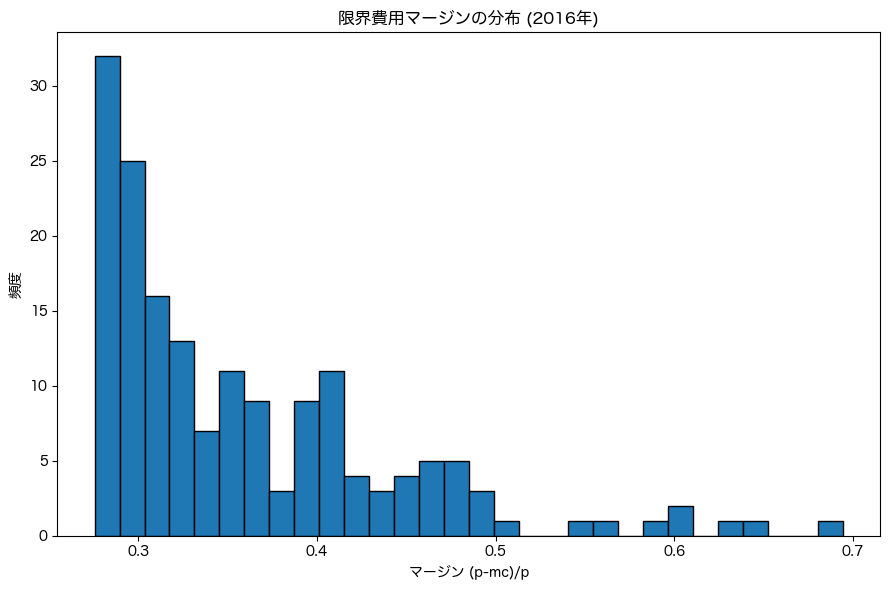

chap5_margin.png を保存しました。


In [16]:
# マージンの分布
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(MC_2016['margin'], bins=30, edgecolor='black')
ax.set_xlabel('マージン (p-mc)/p')
ax.set_ylabel('頻度')
ax.set_title('限界費用マージンの分布 (2016年)')
plt.tight_layout()
plt.savefig(output_dir / 'chap5_margin.png', dpi=150)
plt.show()
print("chap5_margin.png を保存しました。")


## 5. 合併シミュレーション

### 5.1 準備

In [17]:
# 2016年のみ使用
data_2016 = data[data['year'] == 2016].copy().reset_index(drop=True)

# 限界費用をマージ
data_2016 = data_2016.merge(
    MC_2016[['NameID', 'mc']],
    on='NameID', how='left'
)

# 企業名を変更
data_2016['Maker'] = data_2016['Maker'].replace(maker_remap)

# 合併後の企業名
data_2016['MakerNippyoA'] = data_2016['Maker'].replace({
    'Nippyo': 'Nippyo_A', 'Brand_A': 'Nippyo_A'
})
data_2016['MakerNippyoB'] = data_2016['Maker'].replace({
    'Nippyo': 'Nippyo_B', 'Brand_B': 'Nippyo_B'
})

J = len(data_2016)
print(f"2016年の車種数 J = {J}")


2016年の車種数 J = 169


In [18]:
# 所有構造行列の作成
def make_ownership_matrix(maker_col):
    """企業名の列から所有構造行列を作成する。"""
    makers = maker_col.values
    J_local = len(makers)
    O = np.zeros((J_local, J_local))
    for j in range(J_local):
        for k in range(J_local):
            if makers[j] == makers[k]:
                O[j, k] = 1
    return O

Ownership_true = make_ownership_matrix(data_2016['Maker'])
Ownership_NippyoA = make_ownership_matrix(data_2016['MakerNippyoA'])
Ownership_NippyoB = make_ownership_matrix(data_2016['MakerNippyoB'])

print("所有構造行列を作成しました。")
print(f"  合併前の対角ブロック数: {int(Ownership_true.sum())}")
print(f"  Nippyo+A: {int(Ownership_NippyoA.sum())}")
print(f"  Nippyo+B: {int(Ownership_NippyoB.sum())}")


所有構造行列を作成しました。
  合併前の対角ブロック数: 3313
  Nippyo+A: 4069
  Nippyo+B: 3781


In [19]:
# 2016年に絞った状態で推定に必要な行列を作成
mask_2016 = (marketindex == 2016)

X1_2016 = X1[mask_2016, :].copy()
X2_2016 = X2[mask_2016, :].copy()
Z_2016 = Z[mask_2016, :].copy()
ShareVec_2016 = ShareVec[mask_2016, :].copy()
marketindex_2016 = marketindex[mask_2016].copy()

N_2016 = len(marketindex_2016)
T_2016 = len(np.unique(marketindex_2016))

# 乱数 (再設定)
np.random.seed(111)
draw_vec_2016 = np.random.randn(K2 * Nsim)

# マーケットインデックスのダミー行列
uniquemarketindex_2016 = np.sort(np.unique(marketindex_2016))
mkt_denom_d_2016 = (marketindex_2016.reshape(-1, 1) == uniquemarketindex_2016.reshape(1, -1)).astype(float)

# 限界費用とXi
mc_2016 = data_2016['mc'].values
Xi_2016 = data_2016['Xi'].values

print(f"N_2016 = {N_2016}, T_2016 = {T_2016}")


N_2016 = 169, T_2016 = 1


### 5.2 均衡価格の計算

In [20]:
def update_price(X1_sim, X2_sim, mkt_denom_d_sim, draw_vec_sim, Nsim_sim,
                 marketindex_sim, p_old, Ownership, theta1_sim, theta2_sim, mc, Xi_sim):
    """価格を更新する関数 (FOC-based)。"""
    theta2_sim = np.atleast_1d(theta2_sim)

    # datalist内の価格を更新
    X1_temp = X1_sim.copy()
    X1_temp[:, 1] = p_old  # price列(index 1)を更新
    X2_temp = p_old.reshape(-1, 1)

    # deltaを計算
    delta_sim = X1_temp @ theta1_sim.reshape(-1, 1) + Xi_sim.reshape(-1, 1)
    delta_sim = delta_sim.flatten()

    # 市場シェアを求める
    Sharevec = calculate_mktshare(
        X2_temp, mkt_denom_d_sim, draw_vec_sim, Nsim_sim, delta_sim, theta2_sim
    )

    # 価格弾力性を求める
    elas = calculate_elasticity(
        X1_temp, X2_temp, mkt_denom_d_sim, draw_vec_sim, Nsim_sim,
        marketindex_sim, theta1_sim, theta2_sim, delta_sim
    )
    # 2016年のみなので最初のキーを取得
    elas_key = list(elas.keys())[0]
    elasmat = elas[elas_key]

    J_local = len(p_old)
    share_mat = np.tile(Sharevec.reshape(1, -1), (J_local, 1))
    price_mat = np.tile(p_old.reshape(-1, 1), (1, J_local))
    Derivative = -elasmat * share_mat / price_mat
    Delta = Ownership * Derivative

    p_new = mc + np.linalg.solve(Delta, Sharevec)
    return p_new


def solve_equilibrium_price(X1_sim, X2_sim, mkt_denom_d_sim, draw_vec_sim,
                             Nsim_sim, marketindex_sim, p_ini, Ownership,
                             theta1_sim, theta2_sim, mc, Xi_sim):
    """iterationで均衡価格を求める関数。"""
    lam = 1e-6
    p_old = p_ini.copy()
    distance = 10000
    iter_count = 0

    max_iter = 500
    while distance > lam and iter_count < max_iter:
        p_new = update_price(
            X1_sim, X2_sim, mkt_denom_d_sim, draw_vec_sim, Nsim_sim,
            marketindex_sim, p_old, Ownership, theta1_sim, theta2_sim, mc, Xi_sim
        )
        distance = np.max(np.abs(p_new - p_old))
        p_old = p_new
        iter_count += 1
        if iter_count % 50 == 0:
            print(f"  iter={iter_count}, distance={distance:.2e}")

    if iter_count >= max_iter:
        print(f"  警告: 最大反復回数({max_iter})に到達, distance={distance:.2e}")
    else:
        print(f"  収束: iter={iter_count}, distance={distance:.2e}")
    return p_new


def calculate_mktshare_sim(X1_sim, X2_sim, mkt_denom_d_sim, draw_vec_sim,
                            Nsim_sim, p, theta1_sim, theta2_sim, Xi_sim):
    """シミュレートされた価格でのシェアを計算する関数。"""
    theta2_sim = np.atleast_1d(theta2_sim)
    X1_temp = X1_sim.copy()
    X1_temp[:, 1] = p
    X2_temp = p.reshape(-1, 1)

    delta_sim = X1_temp @ theta1_sim.reshape(-1, 1) + Xi_sim.reshape(-1, 1)
    delta_sim = delta_sim.flatten()

    Sharevec = calculate_mktshare(
        X2_temp, mkt_denom_d_sim, draw_vec_sim, Nsim_sim, delta_sim, theta2_sim
    )
    return Sharevec


#### 日評自動車とA社が合併したケースのシミュレーション

In [21]:
# Nippyo-Brand A Simulation
print("Nippyo + Brand A 合併シミュレーション:")
p_ini = data_2016['price'].values.copy()

p_NippyoA = solve_equilibrium_price(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, marketindex_2016, p_ini, Ownership_NippyoA,
    theta1_hat, theta2_hat, mc_2016, Xi_2016
)
data_2016['p_NippyoA'] = p_NippyoA


Nippyo + Brand A 合併シミュレーション:


  iter=50, distance=6.49e-04
  収束: iter=89, distance=9.20e-07


#### 日評自動車とB社が合併したケースのシミュレーション

In [22]:
# Nippyo-Brand B Simulation
print("Nippyo + Brand B 合併シミュレーション:")
p_ini = data_2016['price'].values.copy()

p_NippyoB = solve_equilibrium_price(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, marketindex_2016, p_ini, Ownership_NippyoB,
    theta1_hat, theta2_hat, mc_2016, Xi_2016
)
data_2016['p_NippyoB'] = p_NippyoB


Nippyo + Brand B 合併シミュレーション:


  iter=50, distance=6.01e-04
  収束: iter=86, distance=8.48e-07


In [23]:
# 合併時のシェアを計算
share_NippyoA = calculate_mktshare_sim(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, p_NippyoA, theta1_hat, theta2_hat, Xi_2016
)

share_NippyoB = calculate_mktshare_sim(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, p_NippyoB, theta1_hat, theta2_hat, Xi_2016
)

data_2016['share_NippyoA'] = share_NippyoA
data_2016['share_NippyoB'] = share_NippyoB


### 5.3 シミュレーション結果のまとめ

In [24]:
# 合併シミュレーションによる価格・販売台数変化
data_2016['p_NippyoA_PPC'] = (data_2016['p_NippyoA'] - data_2016['price']) / data_2016['price'] * 100
data_2016['share_NippyoA_PPC'] = (data_2016['share_NippyoA'] - data_2016['share']) / data_2016['share'] * 100
data_2016['p_NippyoB_PPC'] = (data_2016['p_NippyoB'] - data_2016['price']) / data_2016['price'] * 100
data_2016['share_NippyoB_PPC'] = (data_2016['share_NippyoB'] - data_2016['share']) / data_2016['share'] * 100

# 4企業のみ表示
display_makers = ['Nippyo', 'Brand_A', 'Brand_B', 'Brand_C']
Table_5dt = data_2016[data_2016['Maker'].isin(display_makers)][
    ['Maker', 'Name', 'p_NippyoA_PPC', 'share_NippyoA_PPC',
     'p_NippyoB_PPC', 'share_NippyoB_PPC']
].copy()
Table_5dt.columns = ['Maker', 'Name', 'p (NippyoA)', 'q (NippyoA)',
                      'p (NippyoB)', 'q (NippyoB)']

print("合併による価格・販売台数の変化率 (%):")
print(Table_5dt.to_string(index=False))

# 保存
with open(output_dir / 'tab5_1_change_rate.txt', 'w') as f:
    f.write(Table_5dt.to_string(index=False))
print("\ntab5_1_change_rate.txt を保存しました。")


合併による価格・販売台数の変化率 (%):
  Maker      Name  p (NippyoA)  q (NippyoA)  p (NippyoB)  q (NippyoB)
 Nippyo     N-WGN     0.527680    -1.200134     0.182095    -0.479762
 Nippyo     N-ONE     0.524919    -1.210878     0.181198    -0.485168
 Nippyo     N-BOX     0.515336    -1.254919     0.178065    -0.507465
 Nippyo      フィット     0.512501    -1.270668     0.177128    -0.515491
 Nippyo       バモス     0.506564    -1.309947     0.175140    -0.535630
 Nippyo      シャトル     0.493864    -1.486358     0.170337    -0.628153
 Nippyo      グレイス     0.493256    -1.517351     0.169943    -0.644756
 Nippyo      フリード     0.493110    -1.591176     0.169322    -0.684727
 Nippyo      ヴェゼル     0.493379    -1.614009     0.169200    -0.697210
 Nippyo      S660     0.494018    -1.648320     0.169063    -0.716080
 Nippyo   ステップワゴン     0.500629    -1.824182     0.168814    -0.814963
 Nippyo      CR-V     0.506160    -1.926369     0.168651    -0.874217
 Nippyo      ジェイド     0.508113    -1.959536     0.168544    -0.89376

### 5.4 合併後に価格が変化しないような限界費用の変化

In [25]:
# 合併前の弾力性行列 (2016年のみ)
elasmat_2016 = elasticity['elasmat_2016']

def estimate_mc_with_new_ownership(data_sub, elasmat):
    """所有構造を変更した上で、合併前の価格・シェアから逆算した限界費用を推定する。"""
    J_local = len(data_sub)
    price_t = data_sub['price'].values
    share_t = data_sub['share'].values
    makers = data_sub['Maker'].values

    Ownership_t = np.zeros((J_local, J_local))
    for j in range(J_local):
        for k in range(J_local):
            if makers[j] == makers[k]:
                Ownership_t[j, k] = 1

    share_mat = np.tile(share_t.reshape(1, -1), (J_local, 1))
    price_mat = np.tile(price_t.reshape(-1, 1), (1, J_local))
    Derivative_t = -elasmat * share_mat / price_mat
    Delta_t = Ownership_t * Derivative_t

    mc_t = price_t - np.linalg.solve(Delta_t, share_t)
    return mc_t

# Nippyo + Brand A: 所有構造を変えた限界費用
data_2016_NippyoA_mc = data_2016[['year', 'Maker', 'MakerNippyoA', 'Name', 'NameID', 'price', 'share']].copy()
data_2016_NippyoA_mc['Maker'] = data_2016_NippyoA_mc['MakerNippyoA']
mc_NippyoA_pfix = estimate_mc_with_new_ownership(data_2016_NippyoA_mc, elasmat_2016)
data_2016['mc_NippyoA_pfix'] = mc_NippyoA_pfix

# Nippyo + Brand B: 所有構造を変えた限界費用
data_2016_NippyoB_mc = data_2016[['year', 'Maker', 'MakerNippyoB', 'Name', 'NameID', 'price', 'share']].copy()
data_2016_NippyoB_mc['Maker'] = data_2016_NippyoB_mc['MakerNippyoB']
mc_NippyoB_pfix = estimate_mc_with_new_ownership(data_2016_NippyoB_mc, elasmat_2016)
data_2016['mc_NippyoB_pfix'] = mc_NippyoB_pfix

# 限界費用の変化率
data_2016['mc_NippyoA_PPC'] = (data_2016['mc_NippyoA_pfix'] - data_2016['mc']) / data_2016['mc'] * 100
data_2016['mc_NippyoB_PPC'] = (data_2016['mc_NippyoB_pfix'] - data_2016['mc']) / data_2016['mc'] * 100

Table_6dt = data_2016[data_2016['Maker'].isin(display_makers)][
    ['Maker', 'Name', 'mc_NippyoA_PPC', 'mc_NippyoB_PPC']
].copy()
Table_6dt.columns = ['Origin Maker', 'Name', 'Nippyo and Brand A', 'Nippyo and Brand B']

print("合併後に価格を不変にするために必要な限界費用変化率 (%):")
print(Table_6dt.to_string(index=False))

# 保存
with open(output_dir / 'tab5_2_merginal_cost_decrease.txt', 'w') as f:
    f.write(Table_6dt.to_string(index=False))
print("\ntab5_2_merginal_cost_decrease.txt を保存しました。")


合併後に価格を不変にするために必要な限界費用変化率 (%):
Origin Maker      Name  Nippyo and Brand A  Nippyo and Brand B
      Nippyo     N-WGN           -0.928567           -0.357381
      Nippyo     N-ONE           -0.913350           -0.352199
      Nippyo     N-BOX           -0.860956           -0.334548
      Nippyo      フィット           -0.845422           -0.329389
      Nippyo       バモス           -0.812354           -0.318567
      Nippyo      シャトル           -0.725935           -0.292370
      Nippyo      グレイス           -0.717213           -0.290105
      Nippyo      フリード           -0.701159           -0.286422
      Nippyo      ヴェゼル           -0.697306           -0.285688
      Nippyo      S660           -0.692339           -0.284884
      Nippyo   ステップワゴン           -0.678531           -0.285027
      Nippyo      CR-V           -0.676775           -0.287416
      Nippyo      ジェイド           -0.676905           -0.288451
      Nippyo      CR-Z           -0.678695           -0.291854
      Nippyo     オデッセイ  


tab5_2_merginal_cost_decrease.txt を保存しました。


## 6. 厚生分析

In [26]:
def calculate_consumer_surplus(X1_cs, X2_cs, mkt_denom_d_cs, draw_vec_cs,
                                Nsim_cs, p, theta1_cs, theta2_cs, Xi_cs, HH):
    """消費者余剰を計算する関数。
    CS = HH * mean_i(log(1 + sum_j exp(V_ji)) / (-alpha_i))
    """
    theta2_cs = np.atleast_1d(theta2_cs)
    K2_cs = len(theta2_cs)

    # datalist内の価格を更新
    X1_temp = X1_cs.copy()
    X1_temp[:, 1] = p
    X2_temp = p.reshape(-1, 1)

    # deltaを求める
    delta_cs = (X1_temp @ theta1_cs.reshape(-1, 1) + Xi_cs.reshape(-1, 1)).flatten()

    # muを計算
    draw_matrix = draw_vec_cs[:K2_cs * Nsim_cs].reshape(K2_cs, Nsim_cs)
    mu = X2_temp @ np.diag(theta2_cs) @ draw_matrix

    # V = delta * 1' + mu
    V = delta_cs.reshape(-1, 1) @ np.ones((1, Nsim_cs)) + mu
    exp_V = np.exp(V)

    # log(sum_j exp(V_ji) + 1)
    numerator = np.log(exp_V.sum(axis=0) + 1.0)  # (Nsim,)

    # alpha_i = -(theta1[1] + theta2[0] * draw_for_price)
    draw_for_price = draw_matrix[0, :]
    alpha_i = -(theta1_cs[1] + theta2_cs[0] * draw_for_price)  # (Nsim,)

    # CS = HH * mean(numerator / alpha_i)
    CS = HH * np.mean(numerator / alpha_i)
    return CS


def calculate_profit(Maker, price, mc, share, HH):
    """利潤を計算する関数。"""
    profit_each = (price - mc) * share * HH
    revenue_each = price * share * HH

    df = pd.DataFrame({
        'Maker': Maker,
        'profit_each': profit_each,
        'revenue_each': revenue_each
    })

    pro_rev = df.groupby('Maker').agg(
        profit=('profit_each', 'sum'),
        revenue=('revenue_each', 'sum')
    ).reset_index()

    return pro_rev


In [27]:
HH_2016 = data_2016['HH'].unique()[0]

# 合併前のCS
CS_2016 = calculate_consumer_surplus(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, data_2016['price'].values, theta1_hat, theta2_hat, Xi_2016, HH_2016
)

# Nippyo+Brand A 合併後のCS
CS_NippyoA = calculate_consumer_surplus(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, data_2016['p_NippyoA'].values, theta1_hat, theta2_hat, Xi_2016, HH_2016
)

# Nippyo+Brand B 合併後のCS
CS_NippyoB = calculate_consumer_surplus(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, data_2016['p_NippyoB'].values, theta1_hat, theta2_hat, Xi_2016, HH_2016
)

# 補償変分
CV_NippyoA = CS_NippyoA - CS_2016
CV_NippyoB = CS_NippyoB - CS_2016

print(f"CS (合併前): {CS_2016:.1f}")
print(f"CS (Nippyo+A): {CS_NippyoA:.1f}")
print(f"CS (Nippyo+B): {CS_NippyoB:.1f}")
print(f"CV (Nippyo+A): {CV_NippyoA:.1f}")
print(f"CV (Nippyo+B): {CV_NippyoB:.1f}")


CS (合併前): 5331000.2
CS (Nippyo+A): 5365883.4
CS (Nippyo+B): 5380480.3
CV (Nippyo+A): 34883.2
CV (Nippyo+B): 49480.1


In [28]:
# 利潤の計算
pro_rev_2016 = calculate_profit(
    data_2016['Maker'].values, data_2016['price'].values,
    data_2016['mc'].values, data_2016['share'].values, HH_2016
)

pro_rev_NippyoA = calculate_profit(
    data_2016['Maker'].values, data_2016['p_NippyoA'].values,
    data_2016['mc'].values, data_2016['share_NippyoA'].values, HH_2016
)

pro_rev_NippyoB = calculate_profit(
    data_2016['Maker'].values, data_2016['p_NippyoB'].values,
    data_2016['mc'].values, data_2016['share_NippyoB'].values, HH_2016
)

# 総余剰の変化
TS_Change_NippyoA = CV_NippyoA + (pro_rev_NippyoA['profit'].sum() - pro_rev_2016['profit'].sum())
TS_Change_NippyoB = CV_NippyoB + (pro_rev_NippyoB['profit'].sum() - pro_rev_2016['profit'].sum())

# 消費者余剰と総余剰の変化の表
Table_7dt1 = pd.DataFrame({
    'Measure': ['Consumer surplus', 'Total Welfare'],
    'Nippyo and Brand A': [CV_NippyoA, TS_Change_NippyoA],
    'Nippyo and Brand B': [CV_NippyoB, TS_Change_NippyoB]
})

print("消費者余剰と総余剰の変化:")
print(Table_7dt1.to_string(index=False))

# 保存
with open(output_dir / 'tab5_3_1_surplus.txt', 'w') as f:
    f.write(Table_7dt1.to_string(index=False))
print("\ntab5_3_1_surplus.txt を保存しました。")


消費者余剰と総余剰の変化:
         Measure  Nippyo and Brand A  Nippyo and Brand B
Consumer surplus        34883.230151        49480.087528
   Total Welfare        33861.310017        46519.215669

tab5_3_1_surplus.txt を保存しました。


In [29]:
def generate_profit_revenue_table(pro_rev_pre, pro_rev_A, pro_rev_B):
    """利潤と収入の変化テーブルを作成する関数。"""
    # Makerでマージしてから計算
    merged = pro_rev_pre[['Maker']].copy()
    merged['Profits_A'] = pro_rev_A.set_index('Maker').reindex(pro_rev_pre['Maker'].values)['profit'].values - pro_rev_pre['profit'].values
    merged['Revenues_A'] = pro_rev_A.set_index('Maker').reindex(pro_rev_pre['Maker'].values)['revenue'].values - pro_rev_pre['revenue'].values
    merged['Profits_B'] = pro_rev_B.set_index('Maker').reindex(pro_rev_pre['Maker'].values)['profit'].values - pro_rev_pre['profit'].values
    merged['Revenues_B'] = pro_rev_B.set_index('Maker').reindex(pro_rev_pre['Maker'].values)['revenue'].values - pro_rev_pre['revenue'].values

    # Total行を追加
    total_row = pd.DataFrame({
        'Maker': ['Total'],
        'Profits_A': [merged['Profits_A'].sum()],
        'Revenues_A': [merged['Revenues_A'].sum()],
        'Profits_B': [merged['Profits_B'].sum()],
        'Revenues_B': [merged['Revenues_B'].sum()]
    })
    merged = pd.concat([merged, total_row], ignore_index=True)
    merged.columns = ['Maker', 'Profits (NippyoA)', 'Revenues (NippyoA)',
                       'Profits (NippyoB)', 'Revenues (NippyoB)']
    return merged

Table_7dt2 = generate_profit_revenue_table(pro_rev_2016, pro_rev_NippyoA, pro_rev_NippyoB)

print("利潤と収入の変化:")
print(Table_7dt2.to_string(index=False))

# 保存
with open(output_dir / 'tab5_3_2_profit_revenue.txt', 'w') as f:
    f.write(Table_7dt2.to_string(index=False))
print("\ntab5_3_2_profit_revenue.txt を保存しました。")


利潤と収入の変化:
     Maker  Profits (NippyoA)  Revenues (NippyoA)  Profits (NippyoB)  Revenues (NippyoB)
      Audi        -123.241741         -206.153707        -147.193771         -253.713401
       BMW        -284.874977         -445.371148        -346.438645         -580.057060
   Brand_A        -302.402527       -14470.141299        -540.034293         2210.556911
   Brand_B        -195.865973         -255.658514        -302.215466        -5890.173893
   Brand_C       -1725.457875          852.399704       -2400.245445         -402.771143
  Daihatsu         -94.289191          -63.781956        -186.538417         -233.286646
      Fiat          -3.894041           -4.496631          -5.470944           -8.178085
     Lexas        3039.343211        47873.990675        2817.524307        47718.989561
   Matsuda        -148.420064         -173.210781        -209.549701         -308.496364
  Mercedes        -249.127357        18159.821519        -439.458405        18036.487442
Mitsubishi 

## 7. 追加分析: 総余剰を不変にする限界費用削減

総余剰が合併前の水準を保つために必要な、合併企業の限界費用削減率を二分法で計算する。

In [30]:
def calculate_surplus_change(cost_red, cost_red_firms, Ownership,
                              data_sim, X1_sim, X2_sim, mkt_denom_d_sim,
                              draw_vec_sim, Nsim_sim, marketindex_sim,
                              theta1_sim, theta2_sim, HH, p_pre, Xi_sim,
                              pro_rev_pre, CS_pre):
    """特定の企業のみ限界費用を定数倍した時の、総余剰の変化を計算する関数。"""
    # 限界費用を更新
    mc_temp = data_sim['mc'].values.copy()
    mask_firms = data_sim['Maker'].isin(cost_red_firms).values
    mc_temp[mask_firms] = mc_temp[mask_firms] * cost_red

    # 均衡価格
    p_post = solve_equilibrium_price(
        X1_sim, X2_sim, mkt_denom_d_sim, draw_vec_sim,
        Nsim_sim, marketindex_sim, p_pre, Ownership,
        theta1_sim, theta2_sim, mc_temp, Xi_sim
    )

    # CVの計算
    CS_post = calculate_consumer_surplus(
        X1_sim, X2_sim, mkt_denom_d_sim, draw_vec_sim,
        Nsim_sim, p_post, theta1_sim, theta2_sim, Xi_sim, HH
    )
    CV = CS_post - CS_pre

    # 利益と売上の計算
    share_post = calculate_mktshare_sim(
        X1_sim, X2_sim, mkt_denom_d_sim, draw_vec_sim,
        Nsim_sim, p_post, theta1_sim, theta2_sim, Xi_sim
    )

    pro_rev_post = calculate_profit(
        data_sim['Maker'].values, p_post, mc_temp, share_post, HH
    )

    # 総余剰の変化
    TS_Change = CV + (pro_rev_post['profit'].sum() - pro_rev_pre['profit'].sum())
    return TS_Change


In [31]:
# Nippyo + Brand A: 限界費用削減を二分法で計算
print("=" * 60)
print("Nippyo + Brand A: 限界費用削減の計算")
print("=" * 60)

cost_red_firms_A = ['Nippyo', 'Brand_A']
lam = 1e-6
max_cost_red = 1.0
min_cost_red = 0.0
bisect_iter = 0
max_bisect_iter = 50
start_bisect = time.time()

while (max_cost_red - min_cost_red) > lam and bisect_iter < max_bisect_iter:
    mid_cost_red = (max_cost_red + min_cost_red) / 2
    bisect_iter += 1

    mid_eval = calculate_surplus_change(
        mid_cost_red, cost_red_firms_A, Ownership_NippyoA,
        data_2016, X1_2016, X2_2016, mkt_denom_d_2016,
        draw_vec_2016, Nsim, marketindex_2016,
        theta1_hat, theta2_hat, HH_2016, data_2016['p_NippyoA'].values,
        Xi_2016, pro_rev_2016, CS_2016
    )

    if mid_eval > 0:
        min_cost_red = mid_cost_red
    else:
        max_cost_red = mid_cost_red

    interval = max_cost_red - min_cost_red
    elapsed = time.time() - start_bisect
    print(f"  bisect iter={bisect_iter}: cost_red={mid_cost_red:.7f}, TS_change={mid_eval:.6f}, interval={interval:.2e} ({elapsed:.0f}s)")

cost_red_NippyoA = mid_cost_red
print(f"\ncost_red_NippyoA = {cost_red_NippyoA:.7f}")
print(f"必要な費用削減率: {(1 - cost_red_NippyoA) * 100:.5f}%")


Nippyo + Brand A: 限界費用削減の計算


  iter=50, distance=2.17e-03


  iter=100, distance=3.79e-05


  収束: iter=146, distance=9.89e-07
  bisect iter=1: cost_red=0.5000000, TS_change=2268252.580258, interval=5.00e-01 (1s)


  iter=50, distance=8.26e-04


...

  収束: iter=44, distance=8.49e-07
  bisect iter=7: cost_red=0.9921875, TS_change=52286.114061, interval=7.81e-03 (3s)
  収束: iter=39, distance=9.38e-07
  bisect iter=8: cost_red=0.9960938, TS_change=43035.827490, interval=3.91e-03 (3s)


  収束: iter=35, distance=8.99e-07
  bisect iter=9: cost_red=0.9980469, TS_change=38439.158636, interval=1.95e-03 (3s)
  収束: iter=31, distance=8.71e-07
  bisect iter=10: cost_red=0.9990234, TS_change=36147.897990, interval=9.77e-04 (3s)


  収束: iter=27, distance=8.46e-07
  bisect iter=11: cost_red=0.9995117, TS_change=35004.030358, interval=4.88e-04 (3s)
  収束: iter=22, distance=9.70e-07
  bisect iter=12: cost_red=0.9997559, TS_change=34432.538596, interval=2.44e-04 (4s)
  収束: iter=19, distance=8.91e-07
  bisect iter=13: cost_red=0.9998779, TS_change=34146.898966, interval=1.22e-04 (4s)


  収束: iter=17, distance=9.19e-07
  bisect iter=14: cost_red=0.9999390, TS_change=34004.104099, interval=6.10e-05 (4s)
  収束: iter=15, distance=9.45e-07
  bisect iter=15: cost_red=0.9999695, TS_change=33932.712593, interval=3.05e-05 (4s)
  収束: iter=13, distance=9.71e-07
  bisect iter=16: cost_red=0.9999847, TS_change=33897.017754, interval=1.53e-05 (4s)
  収束: iter=11, distance=9.96e-07
  bisect iter=17: cost_red=0.9999924, TS_change=33879.169996, interval=7.63e-06 (4s)


  収束: iter=10, distance=7.13e-07
  bisect iter=18: cost_red=0.9999962, TS_change=33870.245569, interval=3.81e-06 (4s)
  収束: iter=8, distance=7.32e-07
  bisect iter=19: cost_red=0.9999981, TS_change=33865.782613, interval=1.91e-06 (4s)
  収束: iter=6, distance=7.50e-07
  bisect iter=20: cost_red=0.9999990, TS_change=33863.550024, interval=9.54e-07 (4s)

cost_red_NippyoA = 0.9999990
必要な費用削減率: 0.00010%


In [32]:
# 費用削減後の均衡価格とシェア (Nippyo+A)
mc_NippyoA_TSfix = data_2016['mc'].values.copy()
mask_A = data_2016['Maker'].isin(cost_red_firms_A).values
mc_NippyoA_TSfix[mask_A] = mc_NippyoA_TSfix[mask_A] * cost_red_NippyoA
data_2016['mc_NippyoA_TSfix'] = mc_NippyoA_TSfix

print("Nippyo + Brand A: 費用削減後の均衡計算")
p_NippyoA_TSfix = solve_equilibrium_price(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, marketindex_2016, data_2016['p_NippyoA'].values, Ownership_NippyoA,
    theta1_hat, theta2_hat, mc_NippyoA_TSfix, Xi_2016
)

share_NippyoA_TSfix = calculate_mktshare_sim(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, p_NippyoA_TSfix, theta1_hat, theta2_hat, Xi_2016
)

data_2016['p_NippyoA_TSfix'] = p_NippyoA_TSfix
data_2016['share_NippyoA_TSfix'] = share_NippyoA_TSfix


Nippyo + Brand A: 費用削減後の均衡計算
  収束: iter=6, distance=7.50e-07


In [33]:
# Nippyo + Brand B: 限界費用削減を二分法で計算
print("=" * 60)
print("Nippyo + Brand B: 限界費用削減の計算")
print("=" * 60)

cost_red_firms_B = ['Nippyo', 'Brand_B']
lam = 1e-6
max_cost_red = 1.0
min_cost_red = 0.0
bisect_iter = 0
max_bisect_iter = 50
start_bisect = time.time()

while (max_cost_red - min_cost_red) > lam and bisect_iter < max_bisect_iter:
    mid_cost_red = (max_cost_red + min_cost_red) / 2
    bisect_iter += 1

    mid_eval = calculate_surplus_change(
        mid_cost_red, cost_red_firms_B, Ownership_NippyoB,
        data_2016, X1_2016, X2_2016, mkt_denom_d_2016,
        draw_vec_2016, Nsim, marketindex_2016,
        theta1_hat, theta2_hat, HH_2016, data_2016['p_NippyoB'].values,
        Xi_2016, pro_rev_2016, CS_2016
    )

    if mid_eval > 0:
        min_cost_red = mid_cost_red
    else:
        max_cost_red = mid_cost_red

    interval = max_cost_red - min_cost_red
    elapsed = time.time() - start_bisect
    print(f"  bisect iter={bisect_iter}: cost_red={mid_cost_red:.7f}, TS_change={mid_eval:.6f}, interval={interval:.2e} ({elapsed:.0f}s)")

cost_red_NippyoB = mid_cost_red
print(f"\ncost_red_NippyoB = {cost_red_NippyoB:.7f}")
print(f"必要な費用削減率: {(1 - cost_red_NippyoB) * 100:.5f}%")


Nippyo + Brand B: 限界費用削減の計算


  iter=50, distance=4.02e-03


  iter=100, distance=3.51e-06
  収束: iter=109, distance=9.93e-07
  bisect iter=1: cost_red=0.5000000, TS_change=1786663.012846, interval=5.00e-01 (0s)


  iter=50, distance=1.09e-04


  収束: iter=95, distance=9.12e-07
  bisect iter=2: cost_red=0.7500000, TS_change=657725.134440, interval=2.50e-01 (1s)


...

  収束: iter=39, distance=9.50e-07
  bisect iter=7: cost_red=0.9921875, TS_change=60829.804550, interval=7.81e-03 (2s)
  収束: iter=35, distance=9.54e-07
  bisect iter=8: cost_red=0.9960938, TS_change=53644.138794, interval=3.91e-03 (2s)


  収束: iter=31, distance=9.75e-07
  bisect iter=9: cost_red=0.9980469, TS_change=50074.134193, interval=1.95e-03 (2s)
  収束: iter=28, distance=8.35e-07
  bisect iter=10: cost_red=0.9990234, TS_change=48294.801747, interval=9.77e-04 (2s)


  収束: iter=24, distance=8.59e-07
  bisect iter=11: cost_red=0.9995117, TS_change=47406.550631, interval=4.88e-04 (3s)
  収束: iter=20, distance=8.80e-07
  bisect iter=12: cost_red=0.9997559, TS_change=46962.778396, interval=2.44e-04 (3s)
  収束: iter=16, distance=8.90e-07
  bisect iter=13: cost_red=0.9998779, TS_change=46740.981085, interval=1.22e-04 (3s)


  収束: iter=12, distance=8.75e-07
  bisect iter=14: cost_red=0.9999390, TS_change=46630.105428, interval=6.10e-05 (3s)
  収束: iter=9, distance=9.00e-07
  bisect iter=15: cost_red=0.9999695, TS_change=46574.670721, interval=3.05e-05 (3s)
  収束: iter=8, distance=8.43e-07
  bisect iter=16: cost_red=0.9999847, TS_change=46546.948981, interval=1.53e-05 (3s)
  収束: iter=7, distance=7.90e-07
  bisect iter=17: cost_red=0.9999924, TS_change=46533.087330, interval=7.63e-06 (3s)
  収束: iter=6, distance=7.39e-07
  bisect iter=18: cost_red=0.9999962, TS_change=46526.155616, interval=3.81e-06 (3s)
  収束: iter=5, distance=6.92e-07
  bisect iter=19: cost_red=0.9999981, TS_change=46522.688759, interval=1.91e-06 (3s)
  収束: iter=4, distance=6.48e-07


  bisect iter=20: cost_red=0.9999990, TS_change=46520.953990, interval=9.54e-07 (3s)

cost_red_NippyoB = 0.9999990
必要な費用削減率: 0.00010%


In [34]:
# 費用削減後の均衡価格とシェア (Nippyo+B)
mc_NippyoB_TSfix = data_2016['mc'].values.copy()
mask_B = data_2016['Maker'].isin(cost_red_firms_B).values
mc_NippyoB_TSfix[mask_B] = mc_NippyoB_TSfix[mask_B] * cost_red_NippyoB
data_2016['mc_NippyoB_TSfix'] = mc_NippyoB_TSfix

print("Nippyo + Brand B: 費用削減後の均衡計算")
p_NippyoB_TSfix = solve_equilibrium_price(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, marketindex_2016, data_2016['p_NippyoB'].values, Ownership_NippyoB,
    theta1_hat, theta2_hat, mc_NippyoB_TSfix, Xi_2016
)

share_NippyoB_TSfix = calculate_mktshare_sim(
    X1_2016, X2_2016, mkt_denom_d_2016, draw_vec_2016,
    Nsim, p_NippyoB_TSfix, theta1_hat, theta2_hat, Xi_2016
)

data_2016['p_NippyoB_TSfix'] = p_NippyoB_TSfix
data_2016['share_NippyoB_TSfix'] = share_NippyoB_TSfix


Nippyo + Brand B: 費用削減後の均衡計算
  収束: iter=4, distance=6.48e-07


In [35]:
# 費用削減率の表
Table_7dt3 = pd.DataFrame({
    'Measure': ['Cost reduction'],
    'Nippyo and Brand A': [(1 - cost_red_NippyoA) * 100],
    'Nippyo and Brand B': [(1 - cost_red_NippyoB) * 100]
})

print("総余剰を不変にするための限界費用削減率 (%):")
print(Table_7dt3.to_string(index=False))

# 保存
with open(output_dir / 'table_cost_reduction.txt', 'w') as f:
    f.write(Table_7dt3.to_string(index=False))
print("\ntable_cost_reduction.txt を保存しました。")


総余剰を不変にするための限界費用削減率 (%):
       Measure  Nippyo and Brand A  Nippyo and Brand B
Cost reduction            0.000095            0.000095

table_cost_reduction.txt を保存しました。


In [36]:
# 限界費用削減をした場合の利潤と収入の変化

# Nippyo + Brand A
pro_rev_NippyoA_rc = calculate_profit(
    data_2016['Maker'].values,
    data_2016['p_NippyoA_TSfix'].values,
    data_2016['mc_NippyoA_TSfix'].values,
    data_2016['share_NippyoA_TSfix'].values,
    HH_2016
)

# Nippyo + Brand B
pro_rev_NippyoB_rc = calculate_profit(
    data_2016['Maker'].values,
    data_2016['p_NippyoB_TSfix'].values,
    data_2016['mc_NippyoB_TSfix'].values,
    data_2016['share_NippyoB_TSfix'].values,
    HH_2016
)

Table_7dt4 = generate_profit_revenue_table(pro_rev_2016, pro_rev_NippyoA_rc, pro_rev_NippyoB_rc)

print("費用削減後の利潤と収入の変化:")
print(Table_7dt4.to_string(index=False))

# 保存
with open(output_dir / 'table_reduction_profit_revenue.txt', 'w') as f:
    f.write(Table_7dt4.to_string(index=False))
print("\ntable_reduction_profit_revenue.txt を保存しました。")


費用削減後の利潤と収入の変化:
     Maker  Profits (NippyoA)  Revenues (NippyoA)  Profits (NippyoB)  Revenues (NippyoB)
      Audi        -123.243196         -206.158927        -147.194916         -253.717523
       BMW        -284.879930         -445.387422        -346.442553         -580.069943
   Brand_A        -301.975180       -14469.157121        -540.048059         2210.522139
   Brand_B        -195.873123         -255.678154        -302.030301        -5889.683507
   Brand_C       -1725.531769          852.221372       -2400.303685         -402.912204
  Daihatsu         -94.302340          -63.807256        -186.548727         -233.306475
      Fiat          -3.894237           -4.497156          -5.471099           -8.178499
     Lexas        3039.334658        47873.970288        2817.517605        47718.972948
   Matsuda        -148.427654         -173.229945        -209.555674         -308.511466
  Mercedes        -249.134330        18159.794288        -439.463838        18036.466702
Mitsu

In [37]:
# 全体の利潤と収入の変化率
total_profit_pre = pro_rev_2016['profit'].sum()
total_revenue_pre = pro_rev_2016['revenue'].sum()

print("費用削減後の全体の利潤と収入の変化率:")
print(f"  Nippyo+A 利潤変化率: "
      f"{(pro_rev_NippyoA_rc['profit'].sum() - total_profit_pre) / total_profit_pre * 100:.4f}%")
print(f"  Nippyo+A 収入変化率: "
      f"{(pro_rev_NippyoA_rc['revenue'].sum() - total_revenue_pre) / total_revenue_pre * 100:.4f}%")
print(f"  Nippyo+B 利潤変化率: "
      f"{(pro_rev_NippyoB_rc['profit'].sum() - total_profit_pre) / total_profit_pre * 100:.4f}%")
print(f"  Nippyo+B 収入変化率: "
      f"{(pro_rev_NippyoB_rc['revenue'].sum() - total_revenue_pre) / total_revenue_pre * 100:.4f}%")


費用削減後の全体の利潤と収入の変化率:
  Nippyo+A 利潤変化率: -0.0379%
  Nippyo+A 収入変化率: 0.5306%
  Nippyo+B 利潤変化率: -0.1099%
  Nippyo+B 収入変化率: 0.7272%


## まとめ

In [38]:
print("=" * 60)
print("第5章の分析完了")
print("=" * 60)
print("\n出力ファイル:")
for f in sorted(output_dir.glob('*')):
    if f.name.startswith(('tab5_', 'table_', 'chap5_')):
        print(f"  {f.name}")


第5章の分析完了

出力ファイル:
  chap5_margin.pdf
  chap5_margin.png
  tab5_1_change_rate.txt
  tab5_2_merginal_cost_decrease.txt
  tab5_3_1_surplus.txt
  tab5_3_2_profit_revenue.txt
  table_cost_reduction.txt
  table_estimation_result.txt
  table_merginal_cost.txt
  table_reduction_profit_revenue.txt
